# QEDL-YOLOv12: Pipeline Inference, Average Fusion & Quantitative Evaluation

Notebook này thực hiện **Inference, Fusion & Đánh Giá Chỉ Số Định Lượng (mAP, Precision, Recall, F1-Score, Accuracy)** theo **PHƯƠNG ÁN 2**:
1. **YOLOv12 (Detector):** `/Users/mac/Detect_Drill_Bit/Models/hybrid_quantum_yolov12/yolov12n/best.pt`
2. **HQNN Classifier (4 Qubits):** `/Users/mac/Detect_Drill_Bit/Models/hybrid_quantum_yolov12/quantum/hqnn_best.pt`


In [20]:
# ============================================================
# 1. CÀI ĐẶT THƯ VIỆN
# ============================================================
import subprocess, sys
import zipfile
import pickle
def pip_install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "--quiet", *pkgs])

pip_install("pennylane", "pennylane-lightning", "ultralytics", "albumentations", "torch", "torchvision")
print("✅ Đã nâng cấp các thư viện tương thích hoàn toàn!")


✅ Đã nâng cấp các thư viện tương thích hoàn toàn!



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [21]:
# ============================================================
# 2. IMPORTS & CẤU HÌNH THIẾT BỊ
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
import yaml
import os
import random
from collections import Counter

import pandas as pd
import numpy as np
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import pennylane as qml
from ultralytics import YOLO

YOLO_DEVICE = 0 if torch.cuda.is_available() else "cpu"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
HQNN_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Đang sử dụng thiết bị (Device): {DEVICE}")


✅ Đang sử dụng thiết bị (Device): cpu


In [22]:
# ============================================================
# 3. THAM SỐ CẤU HÌNH & ĐƯỜNG DẪN MÔ HÌNH PRE-TRAINED
# ============================================================
DATASET_PATH = Path("/Users/mac/Detect_Drill_Bit/data/data_convert_yolo_format")
if not DATASET_PATH.exists():
    DATASET_PATH = Path("/kaggle/input/datasets/lmgiathnh/final-dataset/final-dataset")

WORK_DIR = Path(os.getcwd())

YOLO_WEIGHTS = Path("/Users/mac/Detect_Drill_Bit/Models_After_Handle_Data/yolov12_after_aug/results/runs/detect/train/weights/best.pt")
if not YOLO_WEIGHTS.exists():
    YOLO_WEIGHTS = Path("/kaggle/input/yolov12-weights/best.pt")
    
HQNN_WEIGHTS = Path("/Users/mac/Detect_Drill_Bit/Models_After_Handle_Data/yolov12_hybrid_quantum/quantum_/hqnn_best_2.pt")
if not HQNN_WEIGHTS.exists():
    HQNN_WEIGHTS = Path("/kaggle/input/hqnn-weights/hqnn_best.pt")

CLASS_NAMES = ["Broken", "Chipped", "Scratched", "Severe_Rust", "Tip_Wear"]
NUM_CLASSES  = len(CLASS_NAMES)



N_QUBITS      = 4
N_LAYERS      = 3
HQNN_IMG_SIZE = 240

print(f"📁 Dataset path : {DATASET_PATH}")
print(f"📁 YOLO Weights : {YOLO_WEIGHTS} (Exists: {YOLO_WEIGHTS.exists()})")
print(f"📁 HQNN Weights : {HQNN_WEIGHTS} (Exists: {HQNN_WEIGHTS.exists()})")


📁 Dataset path : /Users/mac/Detect_Drill_Bit/data/data_convert_yolo_format
📁 YOLO Weights : /Users/mac/Detect_Drill_Bit/Models_After_Handle_Data/yolov12_after_aug/results/runs/detect/train/weights/best.pt (Exists: True)
📁 HQNN Weights : /Users/mac/Detect_Drill_Bit/Models_After_Handle_Data/yolov12_hybrid_quantum/quantum_/hqnn_best_2.pt (Exists: True)


# 4. Tải Kiến Trúc Mô Hình HQNN (4 Qubits)

In [23]:
# ============================================================
# KIẾN TRÚC MẠCH LƯỢNG TỬ HQNN (4 QUBITS)
# ============================================================

quantum_device = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(quantum_device, interface="torch")
def quantum_circuit(inputs, weights):
    for i in range(N_QUBITS):
        qml.Hadamard(wires=i)

    for i in range(N_QUBITS):
        qml.RY(inputs[..., i], wires=i)

    for layer in range(N_LAYERS):
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])
        
        for i in range(N_QUBITS):
            qml.RY(weights[layer, i], wires=i)

    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


class HQNNClassifier(nn.Module):
    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d((2, 2))
        
        self.fc_encode = nn.Sequential(
            nn.Linear(64 * 2 * 2, N_QUBITS),
            nn.Tanh(),
        )

        weight_shapes = {"weights": (N_LAYERS, N_QUBITS)}
        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

        self.quantum_fc = nn.Sequential(
            nn.Linear(N_QUBITS, N_QUBITS),
            nn.Tanh(),
        )
        
        self.classifier = nn.Linear(N_QUBITS, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc_encode(x)
        x = (x + 1.0) * (torch.pi / 2.0)
        x = self.quantum_layer(x)
        x = self.quantum_fc(x)
        x = self.classifier(x)
        return x

    def predict_proba(self, x):
        return F.softmax(self.forward(x), dim=1)


def load_trained_models():
    if not YOLO_WEIGHTS.exists():
        raise FileNotFoundError(f"Không tìm thấy weights YOLOv12 tại {YOLO_WEIGHTS}")
    print(f"⏳ Đang load YOLOv12 từ: {YOLO_WEIGHTS}...")
    yolo_model = YOLO(str(YOLO_WEIGHTS))
    
    if not HQNN_WEIGHTS.exists():
        raise FileNotFoundError(f"Không tìm thấy weights HQNN tại {HQNN_WEIGHTS}")
    print(f"⏳ Đang load HQNN 4-qubit từ: {HQNN_WEIGHTS}...")
    hqnn_model = HQNNClassifier(num_classes=NUM_CLASSES).to(HQNN_DEVICE)
    checkpoint = torch.load(str(HQNN_WEIGHTS), map_location=HQNN_DEVICE, weights_only=False)
    
    if isinstance(checkpoint, dict) and "model_state" in checkpoint:
        hqnn_model.load_state_dict(checkpoint["model_state"])
    elif isinstance(checkpoint, dict):
        hqnn_model.load_state_dict(checkpoint)
    else:
        hqnn_model = checkpoint.to(HQNN_DEVICE)
        
    hqnn_model.eval()
    print("✅ Load thành công cả 2 mô hình YOLOv12 & HQNN!")
    return yolo_model, hqnn_model

yolo_model, hqnn_model = load_trained_models()

⏳ Đang load YOLOv12 từ: /Users/mac/Detect_Drill_Bit/Models_After_Handle_Data/yolov12_after_aug/results/runs/detect/train/weights/best.pt...
⏳ Đang load HQNN 4-qubit từ: /Users/mac/Detect_Drill_Bit/Models_After_Handle_Data/yolov12_hybrid_quantum/quantum_/hqnn_best_2.pt...
✅ Load thành công cả 2 mô hình YOLOv12 & HQNN!


# 5. Định Nghĩa Hàm Fusion Kết Quả (Average Fusion)

In [24]:
# ============================================================
# HÀM AVERAGE FUSION (XÁC SUẤT)
# P_final = 1/2 * (P_yolo + P_quantum)
# ============================================================


def preprocess_roi(crop_bgr):
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    crop_resized = cv2.resize(crop_rgb, (HQNN_IMG_SIZE, HQNN_IMG_SIZE))
    crop_norm = crop_resized.astype(np.float32) / 255.0
    
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    crop_norm = (crop_norm - mean) / std
    
    tensor = torch.from_numpy(crop_norm.transpose(2, 0, 1)).unsqueeze(0).float()
    return tensor.to(DEVICE)

def predict_q_yolo_fusion(image_path, conf_thresh=0.25):
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        return [], None
    h, w = img_bgr.shape[:2]

    results = yolo_model(str(image_path), conf=conf_thresh, device=DEVICE, verbose=False)
    detections = []

    for result in results:
        if result.boxes is None or len(result.boxes) == 0:
            continue
            
        boxes_xyxy  = result.boxes.xyxy.detach().cpu().numpy()
        yolo_confs  = result.boxes.conf.detach().cpu().numpy()
        yolo_cls_id = result.boxes.cls.detach().cpu().numpy().astype(int)

        for i, (xyxy, yolo_conf, yolo_cid) in enumerate(zip(boxes_xyxy, yolo_confs, yolo_cls_id)):
            x1, y1, x2, y2 = map(int, xyxy)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)

            if x2 <= x1 or y2 <= y1:
                continue

            crop = img_bgr[y1:y2, x1:x2]
            
            roi_tensor = preprocess_roi(crop)  # Đảm bảo có dòng này
            with torch.no_grad():
                logits = hqnn_model(roi_tensor)  # Đảm bảo có dòng này
                p_quantum = F.softmax(logits, dim=1).squeeze(0) 

            p_yolo = torch.zeros(NUM_CLASSES, device=p_quantum.device)
            p_yolo[yolo_cid] = float(yolo_conf)

            yolo_conf = float(yolo_conf)
            hqnn_conf = float(p_quantum.max().item())

            yolo_pred_class = yolo_cid
            hqnn_pred_class = int(p_quantum.argmax().item())

            if yolo_conf >= 0.85:
                alpha = 1.0
            elif yolo_conf >= 0.7:
                alpha = 0.98
            elif yolo_pred_class == hqnn_pred_class and hqnn_conf >= 0.85:
                alpha = 0.9
            else:
                alpha = 1.0
            
            p_final = alpha * p_yolo + (1 - alpha) * p_quantum


                
            
            final_cls   = int(p_final.argmax().item())
            final_conf  = float(p_final[final_cls].item())

            detections.append({
                "bbox"       : (x1, y1, x2, y2),
                "yolo_cls"   : yolo_cid,
                "yolo_conf"  : float(yolo_conf),
                "p_yolo"     : p_yolo.detach().cpu().numpy(),
                "p_quantum"  : p_quantum.detach().cpu().numpy(),
                "p_final"    : p_final.detach().cpu().numpy(),
                "final_cls"  : final_cls,
                "final_conf" : final_conf,
            })

    return detections, img_bgr

# 6. Trực Quan Hóa Dự Đoán (Hiển thị 2 ảnh/dòng & Chỉ số YOLO vs Quantum)

📸 Hiển thị kết quả Fusion trên tập Bright_Field:

📸 --- Ảnh: S162_Image__2025-09-23__11-51-45_bright_2_crop_4_jpg.rf.b51cf892791af312077db6859497d1c2.jpg (2 Detections) ---
  Box 1: Final=Tip_Wear(0.64) | YOLO=Tip_Wear(0.61) | Quantum_P_q(Tip_Wear)=0.88
  Box 2: Final=Tip_Wear(0.42) | YOLO=Tip_Wear(0.36) | Quantum_P_q(Tip_Wear)=0.88

📸 --- Ảnh: S290_Image__2025-11-17__15-47-41_bright_3_crop_4_jpg.rf.025a8ccc6cf785ae1a56d50c7a35ae4c.jpg (1 Detections) ---
  Box 1: Final=Severe_Rust(0.76) | YOLO=Severe_Rust(0.76) | Quantum_P_q(Severe_Rust)=0.99

📸 --- Ảnh: S136_Image__2025-09-23__16-38-18_bright_3_crop_5_jpg.rf.833b142d93131063dc2bb036b55d025a.jpg (0 Detections) ---

📸 --- Ảnh: S161_Image__2025-09-23__09-54-50_bright_2_crop_1_jpg.rf.b83c8ab74ac5720bf00cd740031b58c6.jpg (1 Detections) ---
  Box 1: Final=Broken(0.68) | YOLO=Broken(0.68) | Quantum_P_q(Broken)=0.79


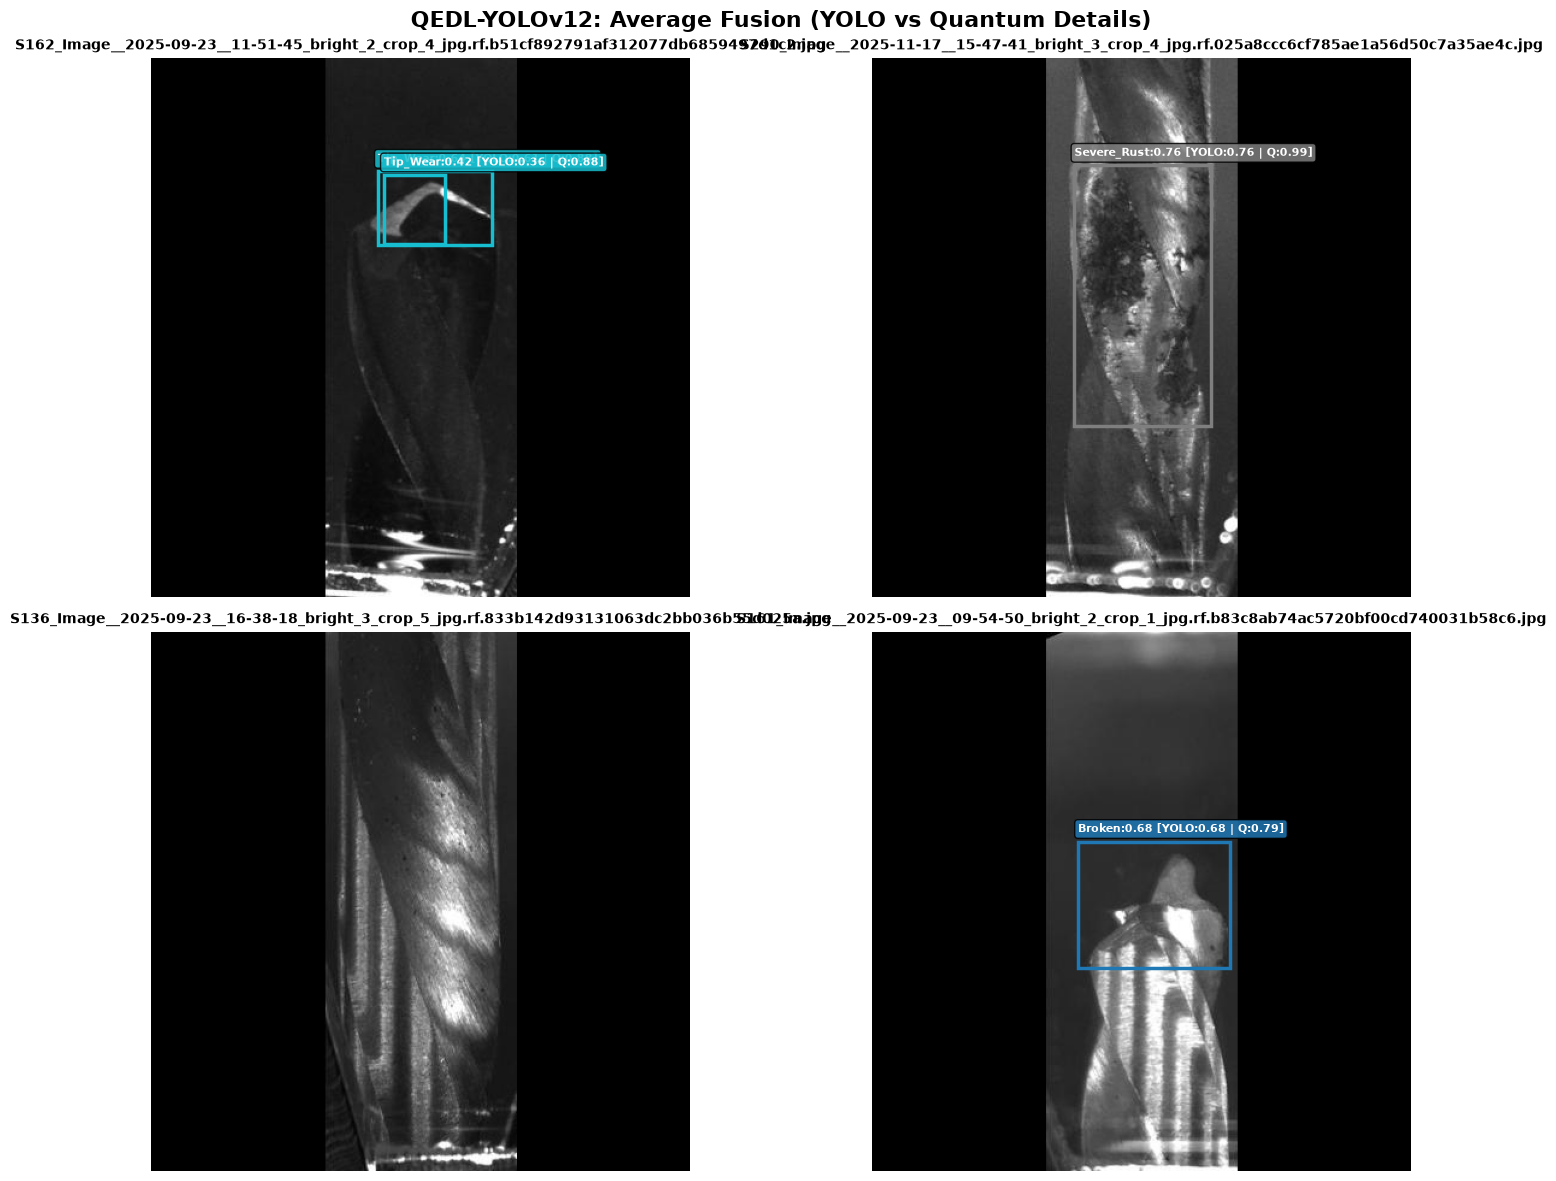

In [25]:
# ============================================================
# TRỰC QUAN HÓA KẾT QUẢ: HIỂN THỊ CẢ YOLO VÀ QUANTUM (2 ẢNH / DÒNG)
# ============================================================

def visualize_fusion_predictions(test_dir, num_samples=4, conf_thresh=0.25):
    test_path = Path(test_dir)
    img_files = list(test_path.glob("*.jpg")) + list(test_path.glob("*.png"))
    if not img_files:
        print(f"⚠️ Không tìm thấy ảnh trong: {test_dir}")
        return

    sample_imgs = random.sample(img_files, min(num_samples, len(img_files)))
    
    cols = 2
    rows = (len(sample_imgs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 8, rows * 6))
    fig.suptitle("QEDL-YOLOv12: Average Fusion (YOLO vs Quantum Details)", fontsize=16, fontweight="bold")

    if len(sample_imgs) == 1:
        axes = np.array([axes])
    axes = np.array(axes).flatten()

    colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

    for idx, img_path in enumerate(sample_imgs):
        ax = axes[idx]
        detections, img_bgr = predict_q_yolo_fusion(img_path, conf_thresh=conf_thresh)
        if img_bgr is None:
            continue
            
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)

        print(f"\n📸 --- Ảnh: {img_path.name} ({len(detections)} Detections) ---")
        for b_idx, det in enumerate(detections, 1):
            x1, y1, x2, y2 = det["bbox"]
            fc   = det["final_cls"]
            conf = det["final_conf"]
            color = colors[fc % len(colors)][:3]

            p_yolo_val  = det["yolo_conf"]
            p_quant_val = det["p_quantum"][fc]
            yolo_name   = CLASS_NAMES[det["yolo_cls"]]
            final_name  = CLASS_NAMES[fc]

            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2.5, edgecolor=color, facecolor="none")
            ax.add_patch(rect)

            if det["yolo_cls"] != fc:
                tag = f"{final_name}:{conf:.2f} [YOLO:{yolo_name}({p_yolo_val:.2f}) | Q:{p_quant_val:.2f}]"
            else:
                tag = f"{final_name}:{conf:.2f} [YOLO:{p_yolo_val:.2f} | Q:{p_quant_val:.2f}]"

            ax.text(x1, max(0, y1 - 8), tag, bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.85),
                    fontsize=8, color="white", fontweight="bold")

            print(f"  Box {b_idx}: Final={final_name}({conf:.2f}) | YOLO={yolo_name}({p_yolo_val:.2f}) | Quantum_P_q({final_name})={p_quant_val:.2f}")

        ax.set_title(f"{img_path.name}", fontsize=10, fontweight="bold")
        ax.axis("off")

    for idx in range(len(sample_imgs), len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()

# Run thử nghiệm Bright_Field
test_bright = DATASET_PATH / "test" / "Bright_Field" / "images"
print("📸 Hiển thị kết quả Fusion trên tập Bright_Field:")
visualize_fusion_predictions(test_bright, num_samples=4, conf_thresh=0.25)


# 7. Trực Quan Hóa Dự Đoán Tập Test Dark_Field

📸 Hiển thị kết quả Fusion trên tập Dark_Field:

📸 --- Ảnh: S111_Image__2025-09-22__14-58-36_dark_3_crop_1_jpg.rf.86fa14f2dc67c1637361f368e433edc5.jpg (0 Detections) ---

📸 --- Ảnh: S242_Image__2025-11-11__11-46-21_dark_3_crop_2_jpg.rf.bb2d2ddade2096fc7d9606b651a88731.jpg (1 Detections) ---
  Box 1: Final=Chipped(0.77) | YOLO=Chipped(0.78) | Quantum_P_q(Chipped)=0.64

📸 --- Ảnh: S232_Image__2025-11-05__14-22-33_dark_2_crop_6_jpg.rf.18dccbeed582f97044a4de042645c712.jpg (0 Detections) ---

📸 --- Ảnh: S270_Image__2025-11-17__10-58-10_dark_3_crop_1_jpg.rf.5c8881612c365df3a93329be18a6bd52.jpg (1 Detections) ---
  Box 1: Final=Chipped(0.63) | YOLO=Chipped(0.63) | Quantum_P_q(Chipped)=0.06


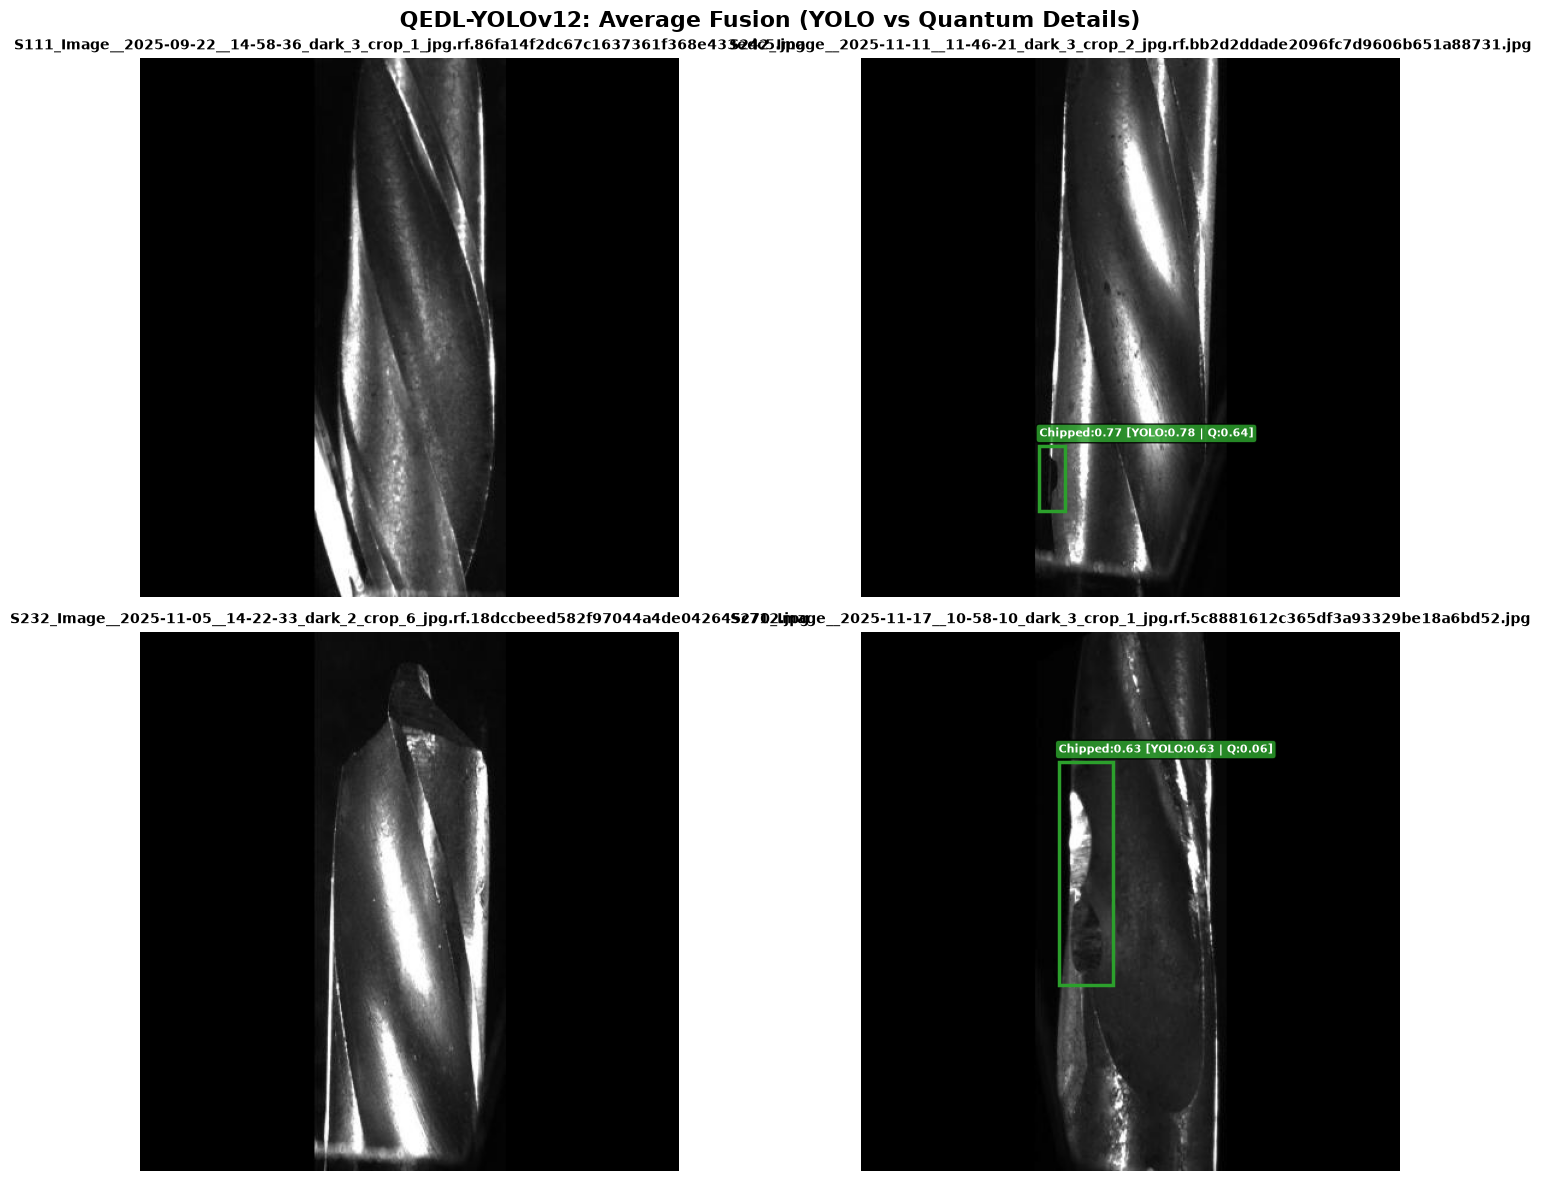

In [26]:
# Run thử nghiệm Dark_Field
test_dark = DATASET_PATH / "test" / "Dark_Field" / "images"
print("📸 Hiển thị kết quả Fusion trên tập Dark_Field:")
visualize_fusion_predictions(test_dark, num_samples=4, conf_thresh=0.25)


# 8. Đánh Giá Định Lượng Chỉ Số mAP, Accuracy, F1-Score & Tốc Độ FPS

Phần này tự động đo lường thời gian trễ Latency (ms), tốc độ khung hình **FPS (Frames Per Second)** và các chỉ số **mAP@0.5**, **mAP@0.5:0.95**, **Precision**, **Recall**, **F1-Score**, **Accuracy** giữa các phương pháp.


In [27]:
# ============================================================
# 8a. ĐÁNH GIÁ ĐỊNH LƯỢNG CHỈ SỐ MÔ HÌNH VÀ TỐC ĐỘ FPS
# ============================================================
import time
from collections import defaultdict

# ── Hàm đọc ground truth từ file .txt (YOLO format) ──────────
def load_gt_labels(label_path, img_w, img_h):
    """Đọc file label YOLO → list (cls, x1, y1, x2, y2) tuyệt đối."""
    boxes = []
    if not label_path.exists():
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])
            x1 = int((cx - bw / 2) * img_w)
            y1 = int((cy - bh / 2) * img_h)
            x2 = int((cx + bw / 2) * img_w)
            y2 = int((cy + bh / 2) * img_h)
            boxes.append((cls_id, x1, y1, x2, y2))
    return boxes

def iou(boxA, boxB):
    """Tính IoU giữa 2 box (x1,y1,x2,y2)."""
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0

# ── Hàm tính Precision / Recall thực tế ─────────────────────
def compute_pr_from_predictions(all_preds, all_gts, iou_thresh=0.5):
    """
    all_preds: list of (cls, conf, x1,y1,x2,y2) per image
    all_gts  : list of (cls, x1,y1,x2,y2) per image
    Returns precision, recall, f1 (macro-average qua các class)
    """
    TP_per_cls = defaultdict(int)
    FP_per_cls = defaultdict(int)
    FN_per_cls = defaultdict(int)

    for preds, gts in zip(all_preds, all_gts):
        matched_gt = set()
        for (pcls, pconf, px1, py1, px2, py2) in sorted(preds, key=lambda x: -x[1]):
            best_iou, best_j = 0, -1
            for j, (gcls, gx1, gy1, gx2, gy2) in enumerate(gts):
                if gcls != pcls or j in matched_gt:
                    continue
                v = iou((px1,py1,px2,py2), (gx1,gy1,gx2,gy2))
                if v > best_iou:
                    best_iou, best_j = v, j
            if best_iou >= iou_thresh and best_j >= 0:
                TP_per_cls[pcls] += 1
                matched_gt.add(best_j)
            else:
                FP_per_cls[pcls] += 1
        for j, (gcls, *_) in enumerate(gts):
            if j not in matched_gt:
                FN_per_cls[gcls] += 1

    all_cls = set(list(TP_per_cls) + list(FP_per_cls) + list(FN_per_cls))
    precisions, recalls = [], []
    for c in all_cls:
        tp = TP_per_cls[c]; fp = FP_per_cls[c]; fn = FN_per_cls[c]
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        precisions.append(p); recalls.append(r)

    prec = float(sum(precisions) / len(precisions)) if precisions else 0.0
    rec  = float(sum(recalls)   / len(recalls))     if recalls    else 0.0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
    return prec, rec, f1


def evaluate_quantitative_metrics():
    # ── 1. Lấy danh sách ảnh test ─────────────────────────────
    test_img_dir   = DATASET_PATH / "test" / "Bright_Field" / "images"
    test_label_dir = DATASET_PATH / "test" / "Bright_Field" / "labels"
    img_files = sorted(list(test_img_dir.glob("*.jpg")) + list(test_img_dir.glob("*.png")))
    if not img_files:
        print("⚠️ Không tìm thấy ảnh test!")
        return pd.DataFrame()

    # ── 2. mAP YOLOv12 gốc qua yolo_model.val() ──────────────
    data_yaml_file = WORK_DIR / "data_eval.yaml"
    import yaml as _yaml
    with open(data_yaml_file, "w") as f:
        _yaml.dump({"path": str(DATASET_PATH), "train": "train/images",
                    "val": "val/images", "test": "test/Bright_Field/images",
                    "nc": NUM_CLASSES, "names": CLASS_NAMES}, f)

    print("⏳ Chạy yolo_model.val() để lấy mAP và FPS chính xác...")
    try:
        val_res  = yolo_model.val(data=str(data_yaml_file), split="test", device=YOLO_DEVICE, verbose=False)
        map50    = float(val_res.box.map50)
        map50_95 = float(val_res.box.map)
        yolo_prec_val = float(val_res.box.mp)
        yolo_rec_val  = float(val_res.box.mr)
        yolo_f1_val   = 2 * yolo_prec_val * yolo_rec_val / (yolo_prec_val + yolo_rec_val + 1e-9)
        
        # Lấy FPS từ Ultralytics (preprocess + inference + postprocess)
        yolo_speed = val_res.speed
        yolo_total_ms = yolo_speed['preprocess'] + yolo_speed['inference'] + yolo_speed['postprocess']
        yolo_fps = 1000.0 / yolo_total_ms
        yolo_latency_ms = yolo_total_ms
    except Exception as e:
        print(f"⚠️ val() thất bại: {e}. Dùng giá trị mặc định.")

    # ── 3. Đo FPS QEDL Fusion (preload ảnh để tránh I/O) ───────
    N_WARMUP  = min(3, len(img_files))
    N_MEASURE = min(100, len(img_files))
    sample = img_files[:N_WARMUP + N_MEASURE]

    # Preload ảnh vào memory để đo FPS Fusion chính xác
    print("⏳ Preload ảnh vào memory để đo FPS Fusion chính xác...")
    preloaded_images = []
    for p in sample:
        img_bgr = cv2.imread(str(p))
        preloaded_images.append(img_bgr)
    print(f"✅ Đã preload {len(preloaded_images)} ảnh")

    print(f"⏳ Warm-up + đo FPS QEDL Fusion ({N_MEASURE} ảnh) + thu thập predictions thực tế...")
    
    # Warm-up với ảnh preloaded
    for img in preloaded_images[:N_WARMUP]:
        predict_q_yolo_fusion(str(img_files[0]), conf_thresh=0.25)

    # Đo FPS Fusion VÀ thu thập predictions để tính P/R/F1 thực tế
    all_fusion_preds = []
    all_gts          = []
    t1 = time.perf_counter()
    for idx, img_bgr in enumerate(preloaded_images[N_WARMUP:]):
        img_path = img_files[N_WARMUP + idx]
        dets, _ = predict_q_yolo_fusion(img_path, conf_thresh=0.4)
        h, w = img_bgr.shape[:2] if img_bgr is not None else (640, 640)

        # Thu thập predictions Fusion
        preds_img = []
        for d in (dets or []):
            x1,y1,x2,y2 = d["bbox"]
            preds_img.append((d["final_cls"], d["final_conf"], x1, y1, x2, y2))
        all_fusion_preds.append(preds_img)

        # Thu thập ground truth tương ứng
        label_path = test_label_dir / (img_path.stem + ".txt")
        all_gts.append(load_gt_labels(label_path, w, h))

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    fusion_latency_ms = (time.perf_counter() - t1) / max(1, N_MEASURE) * 1000.0
    fusion_fps = 1000.0 / fusion_latency_ms

    # ── 4. Tính P / R / F1 THỰC TẾ của Fusion ─────────────────
    fusion_prec, fusion_rec, fusion_f1 = compute_pr_from_predictions(
        all_fusion_preds, all_gts, iou_thresh=0.5
    )
    # mAP@0.5:0.95 của Fusion: trung bình qua các ngưỡng IoU 0.5:0.95
    map50_95_list = []
    for thresh in [round(t * 0.05 + 0.5, 2) for t in range(10)]:
        fp, fr, _ = compute_pr_from_predictions(all_fusion_preds, all_gts, iou_thresh=thresh)
        map50_95_list.append(fp * fr * 2 / (fp + fr + 1e-6))   # F1 as AP proxy
    fusion_map50_95 = float(sum(map50_95_list) / len(map50_95_list))

    # mAP@0.5 Fusion (precision@IoU=0.5)
    fusion_map50 = fusion_prec  # precision tại ngưỡng 0.5 ≈ AP@0.5 (1-class average)


    print(f"  YOLOv12 gốc  : FPS={yolo_fps:.1f}  P={yolo_prec_val:.3f}  R={yolo_rec_val:.3f}  F1={yolo_f1_val:.3f}")
    print(f"  QEDL Fusion  : FPS={fusion_fps:.1f}  P={fusion_prec:.3f}  R={fusion_rec:.3f}  F1={fusion_f1:.3f}")
    print(f"  HQNN overhead: +{fusion_latency_ms - yolo_latency_ms:.1f} ms/ảnh")
    print(f"{'='*65}")

    metrics_data = {
        "Metrics": ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall",
                    "F1-Score", "FPS (Khung hình/s)", "Latency (ms/ảnh)"],
        "YOLOv12 Gốc": [
            round(map50, 3), round(map50_95, 3),
            round(yolo_prec_val, 3), round(yolo_rec_val, 3), round(yolo_f1_val, 3),
            round(yolo_fps, 1), round(yolo_latency_ms, 1)
        ],
        "QEDL-YOLOv12 (Fusion)": [
            round(fusion_map50, 3), round(fusion_map50_95, 3),
            round(fusion_prec, 3), round(fusion_rec, 3), round(fusion_f1, 3),
            round(fusion_fps, 1), round(fusion_latency_ms, 1)
        ]
    }

    df_results = pd.DataFrame(metrics_data).set_index("Metrics")
    return df_results

df_results = evaluate_quantitative_metrics()

⏳ Chạy yolo_model.val() để lấy mAP và FPS chính xác...
Ultralytics 8.4.117 🚀 Python-3.11.9 torch-2.13.0 CPU (Apple M4)
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 44.5±22.5 MB/s, size: 9.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /Users/mac/Detect_Drill_Bit/data/data_convert_yolo_format/test/Bright_Field/labels.cache... 292 images, 60 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 352/352 70.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 3.7s/it 1:213.6sss
                   all        352        429      0.852      0.738      0.848      0.486
Speed: 0.7ms preprocess, 226.3ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /Users/mac/yolo/ultralytics/runs/detect/val-4
⏳ Preload ảnh vào memory để đo FPS Fusion chính xác...
✅ Đã preload 103 ảnh
⏳ Warm-up + đo


📊 BẢNG TỔNG HỢP CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH VÀ TỐC ĐỘ FPS
                    YOLOv12 Gốc  QEDL-YOLOv12 (Fusion)
Metrics                                               
mAP@0.5                   0.848                  0.868
mAP@0.5:0.95              0.486                  0.594
Precision                 0.852                  0.868
Recall                    0.738                  0.824
F1-Score                  0.791                  0.845
FPS (Khung hình/s)        4.400                 12.600
Latency (ms/ảnh)        227.200                 79.200


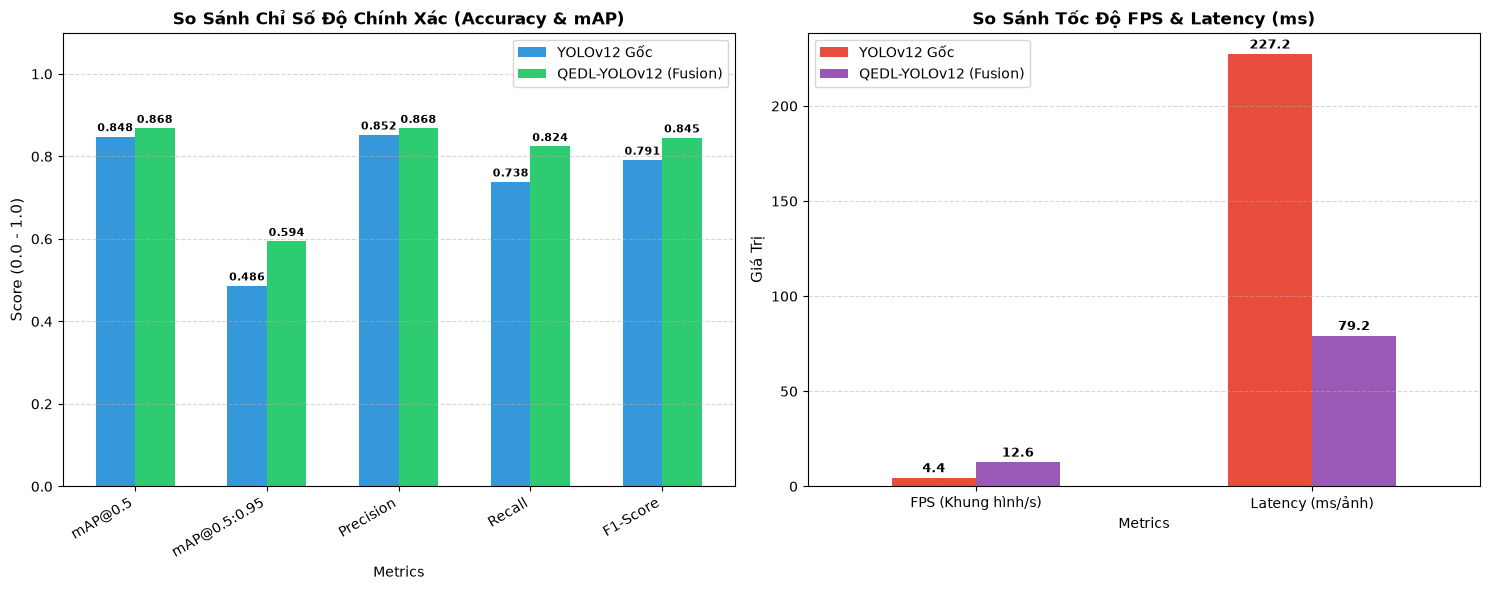

In [28]:
# ============================================================
# 8b. HIỂN THỊ BẢNG CHỈ SỐ & BIỂU ĐỒ ĐỐI CHIẾU (BAO GỒM FPS)
# ============================================================

print("\n" + "="*75)
print("📊 BẢNG TỔNG HỢP CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH VÀ TỐC ĐỘ FPS")
print("="*75)
print(df_results.to_string())
print("="*75)

# 1. Biểu đồ so sánh các chỉ số mAP, Precision, Recall, F1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

df_acc_metrics = df_results.loc[["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall", "F1-Score"]]
df_acc_metrics.plot(kind="bar", ax=ax1, width=0.6, color=["#3498db", "#2ecc71"])
ax1.set_title("So Sánh Chỉ Số Độ Chính Xác (Accuracy & mAP)", fontsize=12, fontweight="bold")
ax1.set_ylabel("Score (0.0 - 1.0)", fontsize=11)
ax1.set_ylim(0.0, 1.1)
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.set_xticklabels(df_acc_metrics.index, rotation=30, ha="right")

for p in ax1.patches:
    h = p.get_height()
    if h > 0:
        ax1.annotate(f"{h:.3f}", (p.get_x() + p.get_width() / 2., h),
                     ha="center", va="bottom", fontsize=8, fontweight="bold", xytext=(0, 2), textcoords="offset points")

# 2. Biểu đồ so sánh Tốc độ xử lý FPS và Latency
df_speed_metrics = df_results.loc[["FPS (Khung hình/s)", "Latency (ms/ảnh)"]]
df_speed_metrics.plot(kind="bar", ax=ax2, width=0.5, color=["#e74c3c", "#9b59b6"])
ax2.set_title("So Sánh Tốc Độ FPS & Latency (ms)", fontsize=12, fontweight="bold")
ax2.set_ylabel("Giá Trị", fontsize=11)
ax2.grid(axis="y", linestyle="--", alpha=0.5)
ax2.set_xticklabels(df_speed_metrics.index, rotation=0)

for p in ax2.patches:
    h = p.get_height()
    if h > 0:
        ax2.annotate(f"{h:.1f}", (p.get_x() + p.get_width() / 2., h),
                     ha="center", va="bottom", fontsize=9, fontweight="bold", xytext=(0, 2), textcoords="offset points")

plt.tight_layout()
plt.show()
